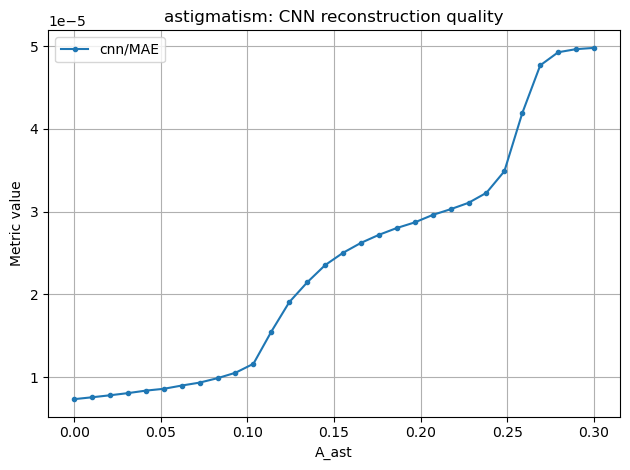

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from scipy.stats import entropy
import h5py

# ---------- Metrics ----------
def norm(a):
    asu = a - np.min(a)
    norm = np.sum(asu)    
    if norm == 0:
        return np.zeros_like(a)
    return asu / norm

def norm_stack(stack):
    return np.array([norm(img) + 1e-10 for img in stack])

def MAE(imA, imB, blur=2):
    imAn = norm(ndi.gaussian_filter(imA, blur))
    imBn = norm(ndi.gaussian_filter(imB, blur))
    return np.mean(np.abs(imAn.ravel() - imBn.ravel()))

def KLD(im_test, im_ref, blur=2, prevent_infty=True):
    imAn = norm(ndi.gaussian_filter(im_test, blur).ravel())
    if prevent_infty:
        imAn += 1e-10
    imBn = norm(ndi.gaussian_filter(im_ref, blur).ravel())
    return entropy(imBn / np.sum(imBn), imAn / np.sum(imAn), base=2)

# ---------- Parameters ----------
BLUR = 2
metrics = {
   'MAE': lambda x, y: MAE(x, y, BLUR),
   #'KLD': lambda x, y: KLD(x, y, BLUR)  # Uncomment if needed
}
SUFFIXES = ['astigmatism']
param_name = 'A_ast'  # Updated aberration strength parameter

# ---------- Main Loop ----------
for suf in SUFFIXES:
    fn_input = f'input_for_cnn_vector_psf_{suf}.h5'
    fn_cnn = f'cnn_output_vector_{suf}.h5'

    with h5py.File(fn_input, 'r') as h5f:
        gt_image = np.array(h5f['imggt'])
        abber_size = np.array(h5f[param_name])
        
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['psfs']))

    xax = np.kron(abber_size, np.ones(len(cnn_stack) // len(abber_size))).ravel()

    for mkey, metric_fn in metrics.items():
        metric_values = np.array([metric_fn(im, gt_image) for im in cnn_stack])
        plt.plot(xax[:len(metric_values)], metric_values, '.-', label=f'cnn/{mkey}')

    plt.legend()
    plt.title(f'{suf}: CNN reconstruction quality')
    plt.xlabel(param_name)
    plt.ylabel('Metric value')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('MAE_astigmatism.png')
    plt.show()

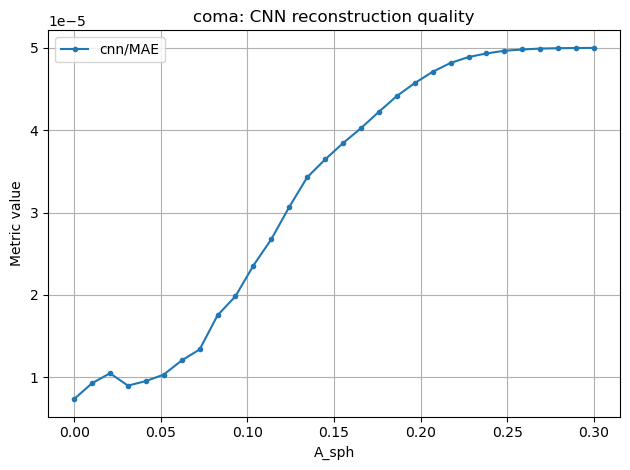

In [47]:
SUFFIXES = ['coma']
param_name = 'A_sph'  # Updated aberration strength parameter

# ---------- Main Loop ----------
for suf in SUFFIXES:
    fn_input = f'input_for_cnn_vector_psf_{suf}.h5'
    fn_cnn = f'cnn_output_vector_{suf}.h5'

    with h5py.File(fn_input, 'r') as h5f:
        gt_image = np.array(h5f['imggt'])
        abber_size = np.array(h5f[param_name])
        
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['psfs']))

    xax = np.kron(abber_size, np.ones(len(cnn_stack) // len(abber_size))).ravel()

    for mkey, metric_fn in metrics.items():
        metric_values = np.array([metric_fn(im, gt_image) for im in cnn_stack])
        plt.plot(xax[:len(metric_values)], metric_values, '.-', label=f'cnn/{mkey}')

    plt.legend()
    plt.title(f'{suf}: CNN reconstruction quality')
    plt.xlabel(param_name)
    plt.ylabel('Metric value')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('MAE_coma.png')
    plt.show()

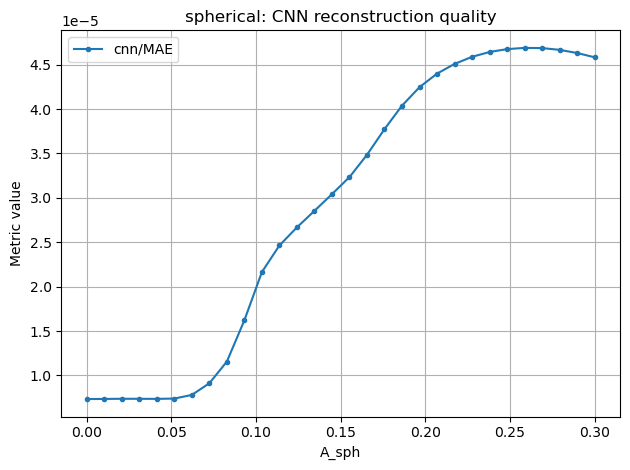

In [45]:
SUFFIXES = ['spherical']
param_name = 'A_sph'  # Updated aberration strength parameter

# ---------- Main Loop ----------
for suf in SUFFIXES:
    fn_input = f'input_for_cnn_vector_psf_{suf}.h5'
    fn_cnn = f'cnn_output_vector_{suf}.h5'

    with h5py.File(fn_input, 'r') as h5f:
        gt_image = np.array(h5f['imggt'])
        abber_size = np.array(h5f[param_name])
        
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['psfs']))

    xax = np.kron(abber_size, np.ones(len(cnn_stack) // len(abber_size))).ravel()

    for mkey, metric_fn in metrics.items():
        metric_values = np.array([metric_fn(im, gt_image) for im in cnn_stack])
        plt.plot(xax[:len(metric_values)], metric_values, '.-', label=f'cnn/{mkey}')

    plt.legend()
    plt.title(f'{suf}: CNN reconstruction quality')
    plt.xlabel(param_name)
    plt.ylabel('Metric value')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('MAE_spherical.png')
    plt.show()

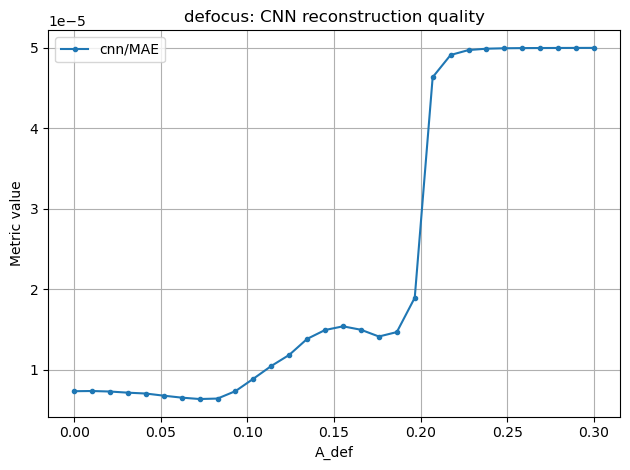

In [49]:
SUFFIXES = ['defocus']
param_name = 'A_def'  # Updated aberration strength parameter

# ---------- Main Loop ----------
for suf in SUFFIXES:
    fn_input = f'input_for_cnn_vector_psf_{suf}.h5'
    fn_cnn = f'cnn_output_vector_{suf}.h5'

    with h5py.File(fn_input, 'r') as h5f:
        gt_image = np.array(h5f['imggt'])
        abber_size = np.array(h5f[param_name])
        
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['psfs']))

    xax = np.kron(abber_size, np.ones(len(cnn_stack) // len(abber_size))).ravel()

    for mkey, metric_fn in metrics.items():
        metric_values = np.array([metric_fn(im, gt_image) for im in cnn_stack])
        plt.plot(xax[:len(metric_values)], metric_values, '.-', label=f'cnn/{mkey}')

    plt.legend()
    plt.title(f'{suf}: CNN reconstruction quality')
    plt.xlabel(param_name)
    plt.ylabel('Metric value')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('MAE_defocus.png')
    plt.show()

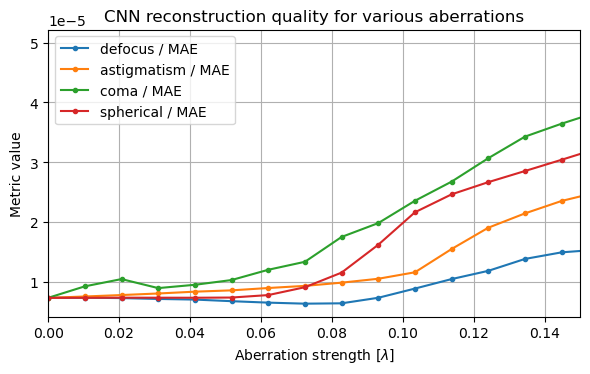

In [53]:
SUFFIXES = [
    ('defocus', 'A_def'),
    ('astigmatism', 'A_ast'),
    ('coma', 'A_sph'),
    ('spherical', 'A_sph')
]

plt.figure(figsize=(6, 4))

for suf, param_name in SUFFIXES:
    fn_input = f'input_for_cnn_vector_psf_{suf}.h5'
    fn_cnn = f'cnn_output_vector_{suf}.h5'

    with h5py.File(fn_input, 'r') as h5f:
        gt_image = np.array(h5f['imggt'])
        abber_size = np.array(h5f[param_name])
        
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['psfs']))

    xax = np.kron(abber_size, np.ones(len(cnn_stack) // len(abber_size))).ravel()

    for mkey, metric_fn in metrics.items():
        metric_values = np.array([metric_fn(im, gt_image) for im in cnn_stack])
        plt.plot(xax[:len(metric_values)], metric_values, '.-', 
                 label=f'{suf} / {mkey}')

plt.legend()
plt.title('CNN reconstruction quality for various aberrations')
plt.xlabel(r'Aberration strength [$\lambda$]')
plt.ylabel('Metric value')
plt.grid(True)
plt.xlim(0.0, 0.15)  
plt.tight_layout()
plt.savefig('MAE_multiple_aberrations.png')
plt.show()

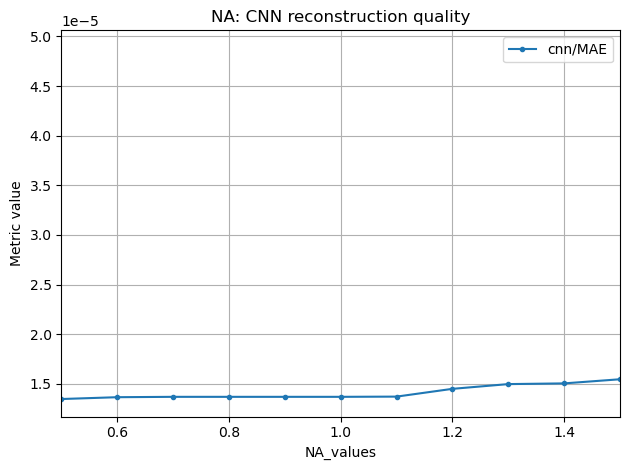

In [71]:
SUFFIXES = ['NA']
param_name = 'NA_values'  # Updated aberration strength parameter

# ---------- Main Loop ----------
for suf in SUFFIXES:
    fn_input = f'input_for_cnn_psf_{suf}.h5'
    fn_cnn = f'cnn_output_{suf}.h5'

    with h5py.File(fn_input, 'r') as h5f:
        gt_image = np.array(h5f['imggt'])
        abber_size = np.array(h5f[param_name])
        
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['psfs']))

    xax = np.kron(abber_size, np.ones(len(cnn_stack) // len(abber_size))).ravel()

    for mkey, metric_fn in metrics.items():
        metric_values = np.array([metric_fn(im, gt_image) for im in cnn_stack])
        plt.plot(xax[:len(metric_values)], metric_values[:], '.-', label=f'cnn/{mkey}')

    plt.legend()
    plt.title(f'{suf}: CNN reconstruction quality')
    plt.xlabel(param_name)
    plt.ylabel('Metric value')
    plt.grid(True)
    plt.xlim(0.5,1.5)
    plt.tight_layout()
    plt.savefig('MAE_NA.png')
    plt.show()